# A Data-Driven Cyber Risk Analytics and Decision Support Framework
## for Digital Banking Environments
**Gerta Rustemi | Student ID: 070124011 | MSc Computer Science, UNYT**

---

# PHASE 1 — Exploratory Data Analysis & Pre-processing

This notebook covers:
1. Environment setup and library imports
2. Dataset loading and initial inspection
3. Data quality audit (nulls, infinities, duplicates, encoding issues)
4. Class distribution analysis and imbalance visualisation
5. Feature-level exploratory analysis
6. Pre-processing pipeline (cleaning → normalisation → SMOTE → PCA → RFE)
7. Saving cleaned dataset for model training (Phase 2)

**Dataset:** CICIDS2017 (1,048,575 records | 79 features | 10 attack categories)  
**Reference:** Canadian Institute for Cybersecurity (2017)

---
## CELL 1 — Install and Import Libraries

In [1]:
# Install any libraries not available by default in Colab
!pip install imbalanced-learn shap --quiet

# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE

# Utilities
from sklearn.model_selection import train_test_split
import os

# Set visual style
plt.style.use('seaborn-v0_8-whitegrid')
TEAL = '#0ABAB5'
DARK_TEAL = '#088A87'

print('✅ All libraries imported successfully')
print(f'pandas: {pd.__version__} | numpy: {np.__version__}')

✅ All libraries imported successfully
pandas: 2.2.3 | numpy: 2.1.3


---
## CELL 2 — Mount Google Drive and Load Dataset

> **Instructions:** Upload `CICIDS2017_Banking_FINAL.csv` to your Google Drive  
> Path example: `My Drive/Thesis/CICIDS2017_Banking_FINAL.csv`

In [2]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# ---- UPDATE THIS PATH to match your Drive folder ----
DATA_PATH = '/content/drive/MyDrive/Thesis/CICIDS2017_Banking_FINAL.csv'
# -----------------------------------------------------

print(f'Loading dataset from: {DATA_PATH}')
print('This may take 1-2 minutes for ~340MB file...')

# Load with encoding fix for Web Attack labels (UTF-8 with latin-1 fallback)
df = pd.read_csv(DATA_PATH, encoding='latin-1')

# Strip leading/trailing spaces from ALL column names (65 columns have leading spaces)
df.columns = df.columns.str.strip()

print(f'\n Dataset loaded successfully')
print(f'Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')

Mounted at /content/drive
Loading dataset from: /content/drive/MyDrive/Thesis/CICIDS2017_Banking_FINAL.csv
This may take 1-2 minutes for ~340MB file...

 Dataset loaded successfully
Shape: 1,048,575 rows × 79 columns


---
## CELL 3 — Initial Inspection

In [3]:
# Basic structure
print('=== DATASET SHAPE ===')
print(f'Rows: {df.shape[0]:,}')
print(f'Columns: {df.shape[1]}')
print(f'Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB')

print('\n=== FIRST 3 ROWS ===')
display(df.head(3))

print('\n=== DATA TYPES ===')
print(df.dtypes.value_counts())

print('\n=== LABEL COLUMN ===')
print(df['Label'].value_counts())

=== DATASET SHAPE ===
Rows: 1,048,575
Columns: 79
Memory usage: 679.2 MB

=== FIRST 3 ROWS ===


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN



=== DATA TYPES ===
int64      54
float64    24
object      1
Name: count, dtype: int64

=== LABEL COLUMN ===
Label
BENIGN                          768515
DDoS                            128027
DoS Hulk                        124723
FTP-Patator                       7938
SSH-Patator                       5897
DoS slowloris                     5796
DoS Slowhttptest                  5499
Web Attack ï¿½ Brute Force        1507
Web Attack ï¿½ XSS                 652
Web Attack ï¿½ Sql Injection        21
Name: count, dtype: int64


---
## CELL 4 — Fix Label Encoding

The Web Attack labels contain encoding artefacts (`Web Attack ï¿½ Brute Force`)  
due to a UTF-8/Latin-1 mismatch in the original CICIDS2017 CSVs. We fix this here.

In [4]:
# Clean label encoding — map all variants to clean names
label_mapping = {
    'BENIGN': 'BENIGN',
    'DDoS': 'DDoS',
    'DoS Hulk': 'DoS Hulk',
    'DoS slowloris': 'DoS Slowloris',
    'DoS Slowhttptest': 'DoS Slowhttptest',
    'FTP-Patator': 'FTP-Patator',
    'SSH-Patator': 'SSH-Patator',
    # Handle encoding variants of Web Attack labels
    'Web Attack \x96 Brute Force': 'Web Attack - Brute Force',
    'Web Attack ï¿½ Brute Force': 'Web Attack - Brute Force',
    'Web Attack \x96 XSS': 'Web Attack - XSS',
    'Web Attack ï¿½ XSS': 'Web Attack - XSS',
    'Web Attack \x96 Sql Injection': 'Web Attack - SQL Injection',
    'Web Attack ï¿½ Sql Injection': 'Web Attack - SQL Injection',
}

# Apply mapping (unmapped labels keep original value)
df['Label'] = df['Label'].map(lambda x: label_mapping.get(x, x))

# Also handle any remaining encoding issues with a regex approach
df['Label'] = df['Label'].str.replace(r'Web Attack .* Brute Force', 'Web Attack - Brute Force', regex=True)
df['Label'] = df['Label'].str.replace(r'Web Attack .* XSS', 'Web Attack - XSS', regex=True)
df['Label'] = df['Label'].str.replace(r'Web Attack .* Sql Injection', 'Web Attack - SQL Injection', regex=True)

print('✅ Label encoding fixed')
print('\nCleaned label distribution:')
print(df['Label'].value_counts())

✅ Label encoding fixed

Cleaned label distribution:
Label
BENIGN                        768515
DDoS                          128027
DoS Hulk                      124723
FTP-Patator                     7938
SSH-Patator                     5897
DoS Slowloris                   5796
DoS Slowhttptest                5499
Web Attack - Brute Force        1507
Web Attack - XSS                 652
Web Attack - SQL Injection        21
Name: count, dtype: int64


---
## CELL 5 — Data Quality Audit

In [5]:
print('=== 1. NULL VALUES ===')
null_counts = df.isnull().sum()
null_cols = null_counts[null_counts > 0]
if len(null_cols) == 0:
    print('No null values found ')
else:
    print(null_cols)

print('\n=== 2. INFINITE VALUES ===')
numeric_df = df.select_dtypes(include=[np.number])
inf_counts = np.isinf(numeric_df).sum()
inf_cols = inf_counts[inf_counts > 0]
print(f'Columns with infinite values: {list(inf_cols.index)}')
print(f'Total infinite values: {inf_cols.sum()}')

print('\n=== 3. DUPLICATE ROWS ===')
n_duplicates = df.duplicated().sum()
print(f'Duplicate rows: {n_duplicates:,} ({n_duplicates/len(df)*100:.2f}%)')

print('\n=== 4. SUMMARY ===')
print(f'Total rows before cleaning: {len(df):,}')
print(f'Issues to fix: {len(null_cols)} null columns, {len(inf_cols)} infinite columns, {n_duplicates:,} duplicates')

=== 1. NULL VALUES ===
Flow Bytes/s    695
dtype: int64

=== 2. INFINITE VALUES ===
Columns with infinite values: ['Flow Bytes/s', 'Flow Packets/s']
Total infinite values: 1221

=== 3. DUPLICATE ROWS ===
Duplicate rows: 72,246 (6.89%)

=== 4. SUMMARY ===
Total rows before cleaning: 1,048,575
Issues to fix: 1 null columns, 2 infinite columns, 72,246 duplicates


---
## CELL 6 — Data Cleaning

In [6]:
rows_before = len(df)

# Step 1: Replace infinite values with NaN, then drop those rows
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Step 2: Drop rows with any null values
df.dropna(inplace=True)

# Step 3: Drop duplicate rows
df.drop_duplicates(inplace=True)

rows_after = len(df)
rows_removed = rows_before - rows_after

print('Data cleaning complete')
print(f'Rows before: {rows_before:,}')
print(f'Rows after:  {rows_after:,}')
print(f'Rows removed: {rows_removed:,} ({rows_removed/rows_before*100:.2f}%)')
print(f'\nFinal shape: {df.shape}')

Data cleaning complete
Rows before: 1,048,575
Rows after:  975,899
Rows removed: 72,676 (6.93%)

Final shape: (975899, 79)


---
## CELL 7 — Class Distribution Visualisation

This is a key dissertation figure demonstrating the class imbalance that motivates SMOTE.

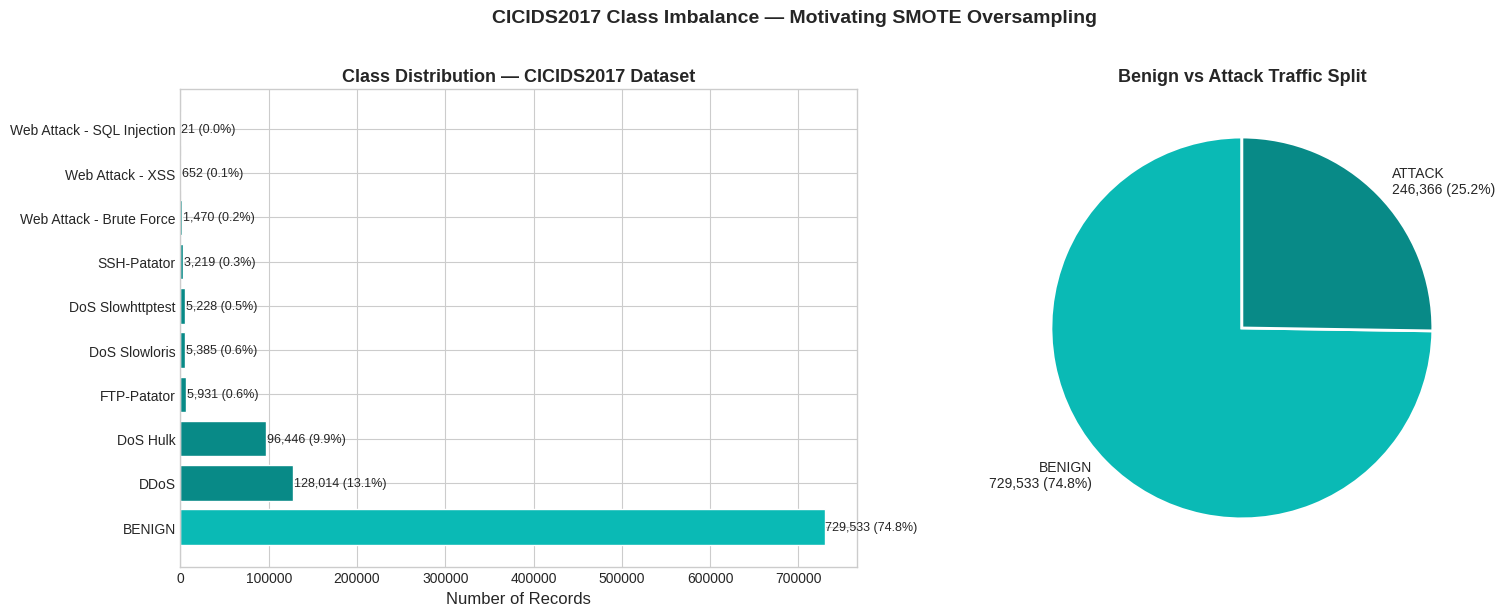


📊 Class distribution table:


,Count,Percentage
Label,,
BENIGN,729533,74.75
DDoS,128014,13.12
DoS Hulk,96446,9.88
FTP-Patator,5931,0.61
DoS Slowloris,5385,0.55
DoS Slowhttptest,5228,0.54
SSH-Patator,3219,0.33
Web Attack - Brute Force,1470,0.15
Web Attack - XSS,652,0.07


In [7]:
label_counts = df['Label'].value_counts()
total = len(df)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Bar chart
colors = [TEAL if label == 'BENIGN' else DARK_TEAL for label in label_counts.index]
bars = axes[0].barh(label_counts.index, label_counts.values, color=colors, edgecolor='white')
axes[0].set_xlabel('Number of Records', fontsize=12)
axes[0].set_title('Class Distribution — CICIDS2017 Dataset', fontsize=13, fontweight='bold')
for bar, val in zip(bars, label_counts.values):
    axes[0].text(bar.get_width() + 1000, bar.get_y() + bar.get_height()/2,
                f'{val:,} ({val/total*100:.1f}%)', va='center', fontsize=9)

# Right: Benign vs Attack split
benign = label_counts.get('BENIGN', 0)
attack = total - benign
axes[1].pie(
    [benign, attack],
    labels=[f'BENIGN\n{benign:,} ({benign/total*100:.1f}%)',
            f'ATTACK\n{attack:,} ({attack/total*100:.1f}%)'],
    colors=[TEAL, DARK_TEAL],
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[1].set_title('Benign vs Attack Traffic Split', fontsize=13, fontweight='bold')

plt.suptitle('CICIDS2017 Class Imbalance — Motivating SMOTE Oversampling',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n📊 Class distribution table:')
summary = pd.DataFrame({
    'Count': label_counts,
    'Percentage': (label_counts / total * 100).round(2)
})
display(summary)

---
## CELL 8 — Feature Distribution EDA

Examine the most important network flow features across attack categories.

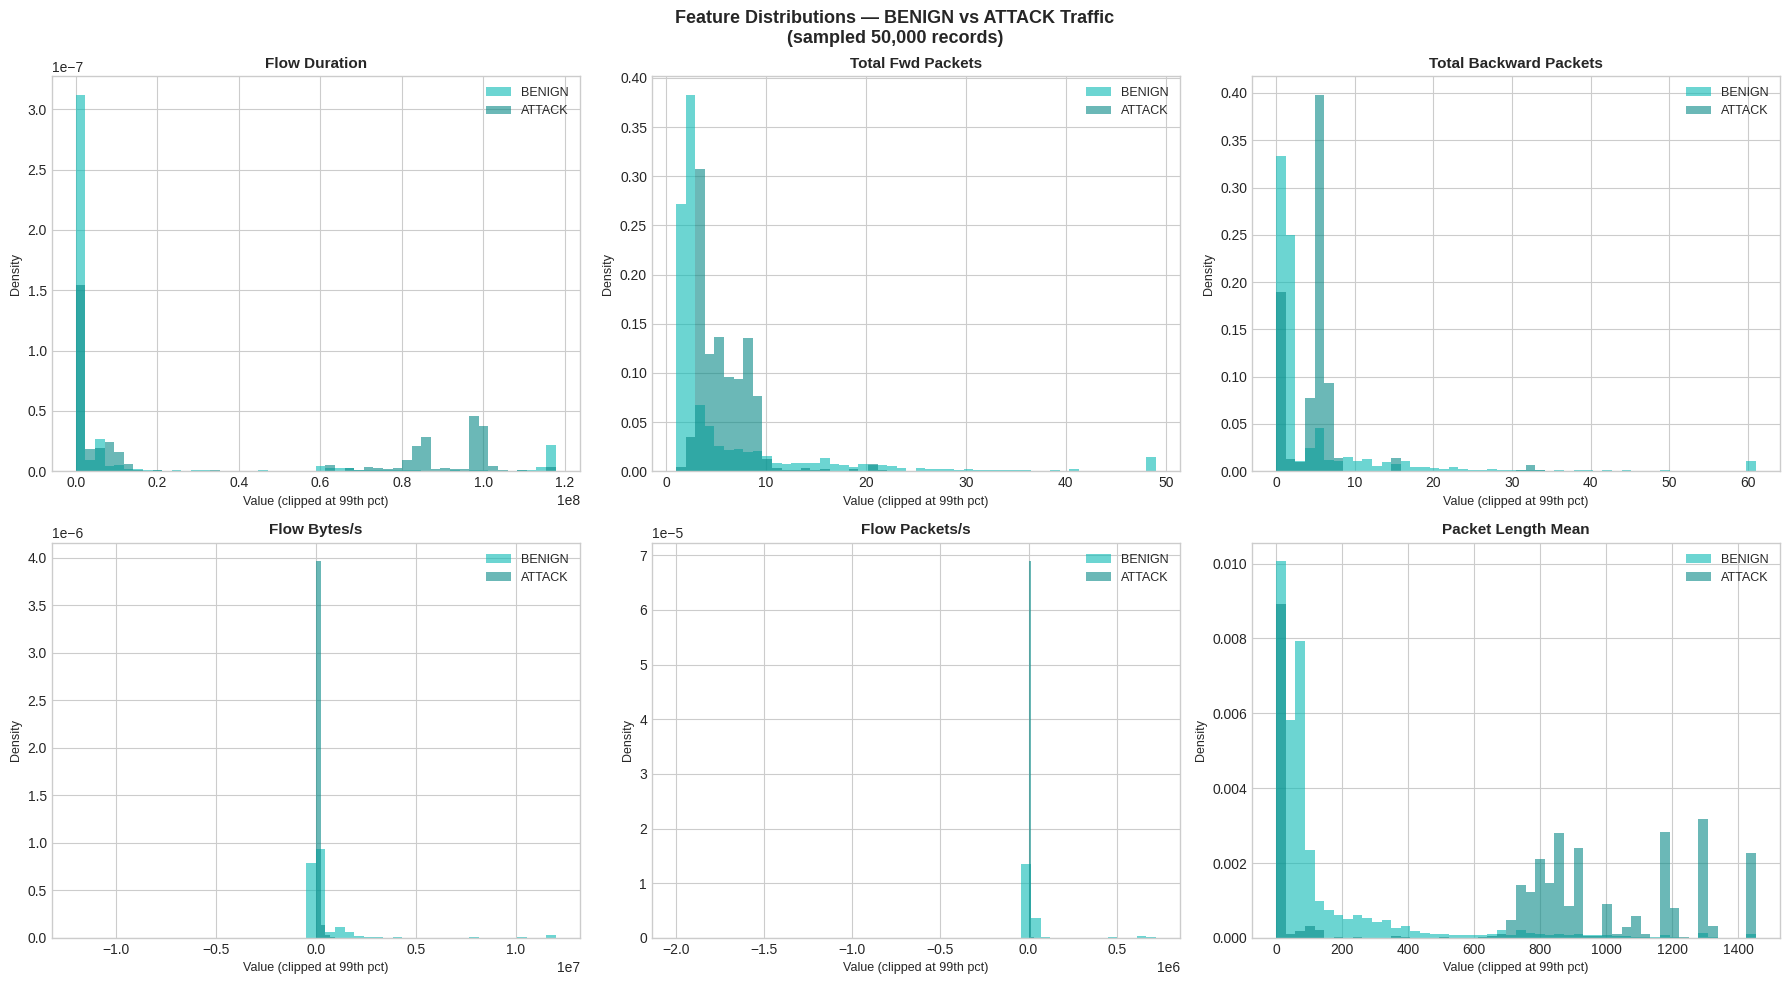

In [8]:
# Key features to explore (from CICIDS2017 literature)
key_features = [
    'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets',
    'Flow Bytes/s', 'Flow Packets/s', 'Packet Length Mean'
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

# Sample for faster plotting
df_sample = df.sample(n=min(50000, len(df)), random_state=42)

for i, feature in enumerate(key_features):
    if feature in df_sample.columns:
        # Plot benign vs attack distributions
        benign_data = df_sample[df_sample['Label'] == 'BENIGN'][feature]
        attack_data = df_sample[df_sample['Label'] != 'BENIGN'][feature]

        # Clip outliers for visualisation (99th percentile)
        clip_val = df_sample[feature].quantile(0.99)
        benign_clipped = benign_data.clip(upper=clip_val)
        attack_clipped = attack_data.clip(upper=clip_val)

        axes[i].hist(benign_clipped, bins=50, alpha=0.6, color=TEAL, label='BENIGN', density=True)
        axes[i].hist(attack_clipped, bins=50, alpha=0.6, color=DARK_TEAL, label='ATTACK', density=True)
        axes[i].set_title(feature, fontsize=11, fontweight='bold')
        axes[i].set_xlabel('Value (clipped at 99th pct)', fontsize=9)
        axes[i].set_ylabel('Density', fontsize=9)
        axes[i].legend(fontsize=9)

plt.suptitle('Feature Distributions — BENIGN vs ATTACK Traffic\n(sampled 50,000 records)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

---
## CELL 9 — Correlation Heatmap

Identifies highly correlated features — inputs to RFE feature selection.

Highly correlated feature pairs (|r| > 0.95): 58
  Total Backward Packets ↔ Total Fwd Packets: r=0.996
  Total Length of Bwd Packets ↔ Total Fwd Packets: r=0.997
  Total Length of Bwd Packets ↔ Total Backward Packets: r=0.997
  Fwd Packet Length Std ↔ Fwd Packet Length Max: r=0.981
  Bwd Packet Length Mean ↔ Bwd Packet Length Max: r=0.96
  Bwd Packet Length Std ↔ Bwd Packet Length Max: r=0.986
  Flow IAT Max ↔ Flow IAT Std: r=0.951
  Fwd IAT Total ↔ Flow Duration: r=0.999
  Fwd IAT Max ↔ Flow IAT Max: r=0.998
  Fwd Header Length ↔ Total Fwd Packets: r=0.992


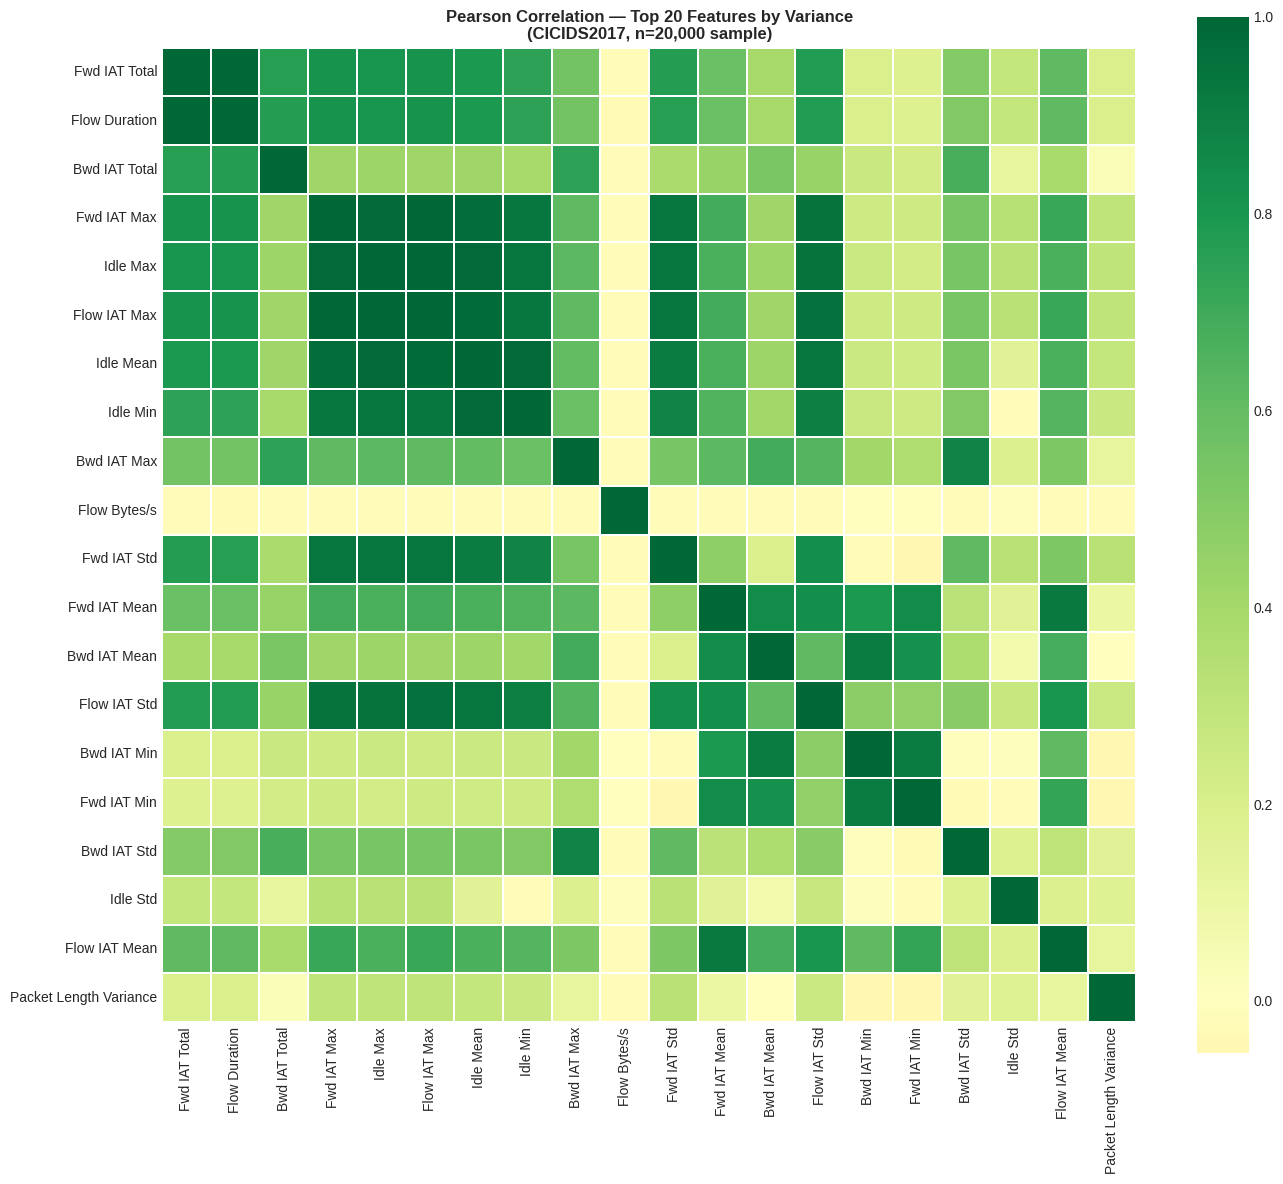

In [9]:
# Sample for correlation (full dataset too large)
df_corr = df.select_dtypes(include=[np.number]).sample(n=20000, random_state=42)
corr_matrix = df_corr.corr()

# Find highly correlated pairs (>0.95)
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > 0.95:
            high_corr_pairs.append((
                corr_matrix.columns[i],
                corr_matrix.columns[j],
                round(corr_matrix.iloc[i, j], 3)
            ))

print(f'Highly correlated feature pairs (|r| > 0.95): {len(high_corr_pairs)}')
for pair in high_corr_pairs[:10]:
    print(f'  {pair[0]} ↔ {pair[1]}: r={pair[2]}')

# Plot condensed heatmap (too many features for full 79x79)
# Show top 20 features by variance
top_features = df_corr.var().nlargest(20).index
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    df_corr[top_features].corr(),
    annot=False,
    cmap='RdYlGn',
    center=0,
    square=True,
    linewidths=0.3,
    ax=ax
)
ax.set_title('Pearson Correlation — Top 20 Features by Variance\n(CICIDS2017, n=20,000 sample)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

---
## CELL 10 — Encode Labels and Separate Features

In [10]:
# Separate features and target
X = df.drop(columns=['Label'])
y_raw = df['Label']

# Encode labels to integers
le = LabelEncoder()
y = le.fit_transform(y_raw)

# Save the mapping for reference
label_mapping_encoded = dict(zip(le.classes_, le.transform(le.classes_)))
print('Label encoding mapping:')
for label, code in sorted(label_mapping_encoded.items(), key=lambda x: x[1]):
    count = (y_raw == label).sum()
    print(f'  {code}: {label} ({count:,} records)')

print(f'\nFeature matrix shape: {X.shape}')
print(f'Target vector shape: {y.shape}')

Label encoding mapping:
  0: BENIGN (729,533 records)
  1: DDoS (128,014 records)
  2: DoS Hulk (96,446 records)
  3: DoS Slowhttptest (5,228 records)
  4: DoS Slowloris (5,385 records)
  5: FTP-Patator (5,931 records)
  6: SSH-Patator (3,219 records)
  7: Web Attack - Brute Force (1,470 records)
  8: Web Attack - SQL Injection (21 records)
  9: Web Attack - XSS (652 records)

Feature matrix shape: (975899, 78)
Target vector shape: (975899,)


---
## CELL 11 — StandardScaler Normalisation

In [11]:
## CELL 11 — Train/Test Split BEFORE Scaling and SMOTE

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(' Train/test split complete (80/20, stratified)')
print(f'Training set: {X_train_raw.shape[0]:,} rows')
print(f'Test set:     {X_test_raw.shape[0]:,} rows')

train_counts = pd.Series(y_train).value_counts().sort_index()
for code, count in train_counts.items():
    label = le.inverse_transform([code])[0]
    print(f'  {label}: {count:,}')

 Train/test split complete (80/20, stratified)
Training set: 780,719 rows
Test set:     195,180 rows
  BENIGN: 583,626
  DDoS: 102,411
  DoS Hulk: 77,157
  DoS Slowhttptest: 4,182
  DoS Slowloris: 4,308
  FTP-Patator: 4,745
  SSH-Patator: 2,575
  Web Attack - Brute Force: 1,176
  Web Attack - SQL Injection: 17
  Web Attack - XSS: 522


## CELL 12 — StandardScaler Normalisation (fit on training only)

> ⚠️ **Critical:** Scaler must be fit on training data only.
> Fitting it on the full dataset before splitting would leak test-set statistics into training.

In [12]:
## CELL 12 — StandardScaler Normalisation (fit on training only)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled  = scaler.transform(X_test_raw)

X_train = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test  = pd.DataFrame(X_test_scaled,  columns=X.columns)

print(' StandardScaler fitted on training data only, applied to both splits')
print('\nBefore scaling — Flow Duration stats (train):')
print(X_train_raw['Flow Duration'].describe())
print('\nAfter scaling — Flow Duration stats (train):')
print(X_train['Flow Duration'].describe())

 StandardScaler fitted on training data only, applied to both splits

Before scaling — Flow Duration stats (train):
count    7.807190e+05
mean     2.056475e+07
std      3.787360e+07
min     -4.000000e+00
25%      1.201500e+03
50%      1.372230e+05
75%      9.546172e+06
max      1.200000e+08
Name: Flow Duration, dtype: float64

After scaling — Flow Duration stats (train):
count    7.807190e+05
mean     1.818406e-17
std      1.000001e+00
min     -5.429842e-01
25%     -5.429524e-01
50%     -5.393610e-01
75%     -2.909305e-01
max      2.625452e+00
Name: Flow Duration, dtype: float64


---
## CELL 13 — SMOTE Class Balancing

Applied to training data only. Generates synthetic minority-class samples  
to address the 73%/27% benign/attack imbalance (Géron, 2020).

> ⚠️ **Note:** SMOTE on 800k+ rows is memory-intensive. This cell may take 5-15 minutes.  
> If memory errors occur, use the subsampled version in the comment below.

In [13]:
print('Applying SMOTE to training data...')
print('(This may take several minutes on the full dataset)')

# SMOTE with k_neighbors=5 (default) — standard configuration
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print('\n SMOTE applied successfully')
print(f'Training set before SMOTE: {X_train.shape[0]:,} rows')
print(f'Training set after SMOTE:  {X_train_sm.shape[0]:,} rows')

print('\nClass distribution AFTER SMOTE (training set):')
after_counts = pd.Series(y_train_sm).value_counts().sort_index()
for code, count in after_counts.items():
    label = le.inverse_transform([code])[0]
    print(f'  {label}: {count:,}')

Applying SMOTE to training data...
(This may take several minutes on the full dataset)

 SMOTE applied successfully
Training set before SMOTE: 780,719 rows
Training set after SMOTE:  5,836,260 rows

Class distribution AFTER SMOTE (training set):
  BENIGN: 583,626
  DDoS: 583,626
  DoS Hulk: 583,626
  DoS Slowhttptest: 583,626
  DoS Slowloris: 583,626
  FTP-Patator: 583,626
  SSH-Patator: 583,626
  Web Attack - Brute Force: 583,626
  Web Attack - SQL Injection: 583,626
  Web Attack - XSS: 583,626


---
## CELL 14 — PCA Dimensionality Reduction

Two purposes: (1) reduce 79 features for training efficiency,  
(2) enable 2D risk cluster visualisations for governance stakeholders.

 PCA complete
Original features: 79
PCA components retained: 16 (explaining 95.3% of variance)


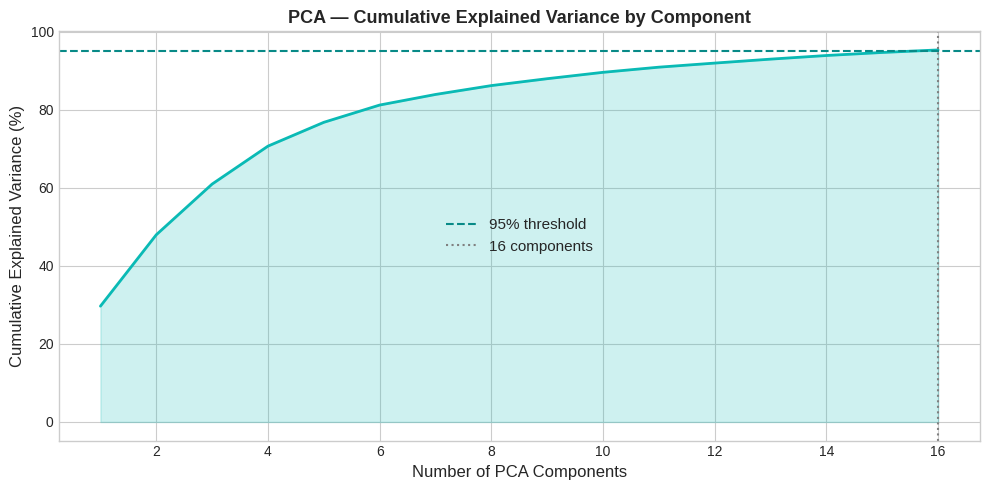

In [14]:
# Fit PCA on SMOTE-balanced training data
pca = PCA(n_components=0.95, random_state=42)  # Retain 95% of variance
X_train_pca = pca.fit_transform(X_train_sm)
X_test_pca = pca.transform(X_test)

n_components_kept = pca.n_components_
variance_explained = pca.explained_variance_ratio_.cumsum()[-1]

print(f' PCA complete')
print(f'Original features: 79')
print(f'PCA components retained: {n_components_kept} (explaining {variance_explained*100:.1f}% of variance)')

# Plot explained variance
fig, ax = plt.subplots(figsize=(10, 5))
cumvar = pca.explained_variance_ratio_.cumsum()
ax.plot(range(1, len(cumvar)+1), cumvar * 100, color=TEAL, linewidth=2)
ax.axhline(y=95, color=DARK_TEAL, linestyle='--', label='95% threshold')
ax.axvline(x=n_components_kept, color='gray', linestyle=':', label=f'{n_components_kept} components')
ax.fill_between(range(1, len(cumvar)+1), cumvar * 100, alpha=0.2, color=TEAL)
ax.set_xlabel('Number of PCA Components', fontsize=12)
ax.set_ylabel('Cumulative Explained Variance (%)', fontsize=12)
ax.set_title('PCA — Cumulative Explained Variance by Component', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('pca_explained_variance.png', dpi=150, bbox_inches='tight')
plt.show()

---
## CELL 15 — 2D PCA Risk Cluster Visualisation

A key governance-facing output: shows how attack categories cluster in 2D feature space.

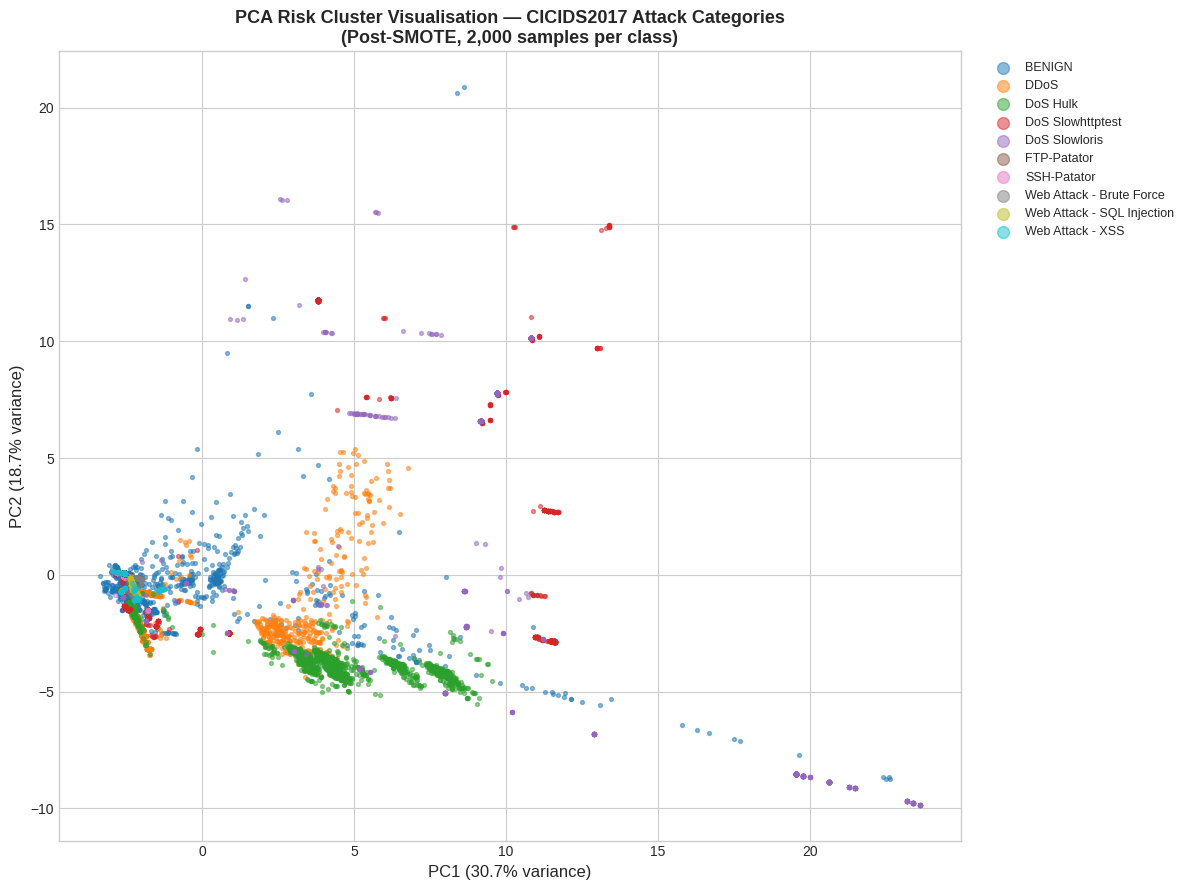

PCA risk cluster visualisation saved


In [15]:
# Use first 2 PCA components for visualisation
pca_2d = PCA(n_components=2, random_state=42)

# Sample for speed (10k records per class max)
df_vis = pd.DataFrame(X_train_sm)
df_vis['label'] = y_train_sm
df_vis_sampled = df_vis.groupby('label').apply(
    lambda x: x.sample(n=min(2000, len(x)), random_state=42)
).reset_index(drop=True)

X_vis = pca_2d.fit_transform(df_vis_sampled.drop(columns=['label']))
y_vis = df_vis_sampled['label'].values

# Plot
label_names = le.inverse_transform(sorted(df_vis_sampled['label'].unique()))
cmap = plt.cm.get_cmap('tab10', len(label_names))

fig, ax = plt.subplots(figsize=(12, 9))
for i, label_code in enumerate(sorted(df_vis_sampled['label'].unique())):
    mask = y_vis == label_code
    label_name = le.inverse_transform([label_code])[0]
    ax.scatter(X_vis[mask, 0], X_vis[mask, 1],
               label=label_name, alpha=0.5, s=8, color=cmap(i))

ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% variance)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% variance)', fontsize=12)
ax.set_title('PCA Risk Cluster Visualisation — CICIDS2017 Attack Categories\n(Post-SMOTE, 2,000 samples per class)',
             fontsize=13, fontweight='bold')
ax.legend(markerscale=3, fontsize=9, bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig('pca_risk_clusters.png', dpi=150, bbox_inches='tight')
plt.show()
print('PCA risk cluster visualisation saved')

---
## CELL 16 — RFE Feature Selection

Recursive Feature Elimination using Random Forest to identify  
the most informative features from the 79 available.

In [16]:
print('Running RFE with Random Forest estimator...')
print('(Using sample of 50,000 records for speed — RFE is computationally expensive)')

# Sample for RFE — use original (pre-SMOTE) scaled training data
# RFE is used for feature insight, models will train on full SMOTE data
rng = np.random.RandomState(42)
sample_idx = rng.choice(X_train.shape[0], size=min(50000, X_train.shape[0]), replace=False)
X_rfe = X_train.iloc[sample_idx]
y_rfe = y_train[sample_idx]

# RFE with Random Forest
rf_estimator = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
rfe = RFE(estimator=rf_estimator, n_features_to_select=20, step=5)
rfe.fit(X_rfe, y_rfe)

# Get selected features
selected_features = X_train.columns[rfe.support_].tolist()
feature_rankings = pd.Series(rfe.ranking_, index=X_train.columns).sort_values()

print(f'\n RFE complete — Top 20 selected features:')
for i, feat in enumerate(selected_features, 1):
    print(f'  {i:2d}. {feat}')

Running RFE with Random Forest estimator...
(Using sample of 50,000 records for speed — RFE is computationally expensive)

 RFE complete — Top 20 selected features:
   1. Total Length of Fwd Packets
   2. Total Length of Bwd Packets
   3. Fwd Packet Length Max
   4. Fwd Packet Length Mean
   5. Bwd Packet Length Max
   6. Bwd Packet Length Mean
   7. Bwd Packet Length Std
   8. Fwd IAT Std
   9. Fwd IAT Max
  10. Bwd Header Length
  11. Bwd Packets/s
  12. Packet Length Std
  13. Packet Length Variance
  14. Average Packet Size
  15. Avg Bwd Segment Size
  16. Fwd Header Length.1
  17. Subflow Fwd Packets
  18. Subflow Fwd Bytes
  19. Subflow Bwd Bytes
  20. act_data_pkt_fwd


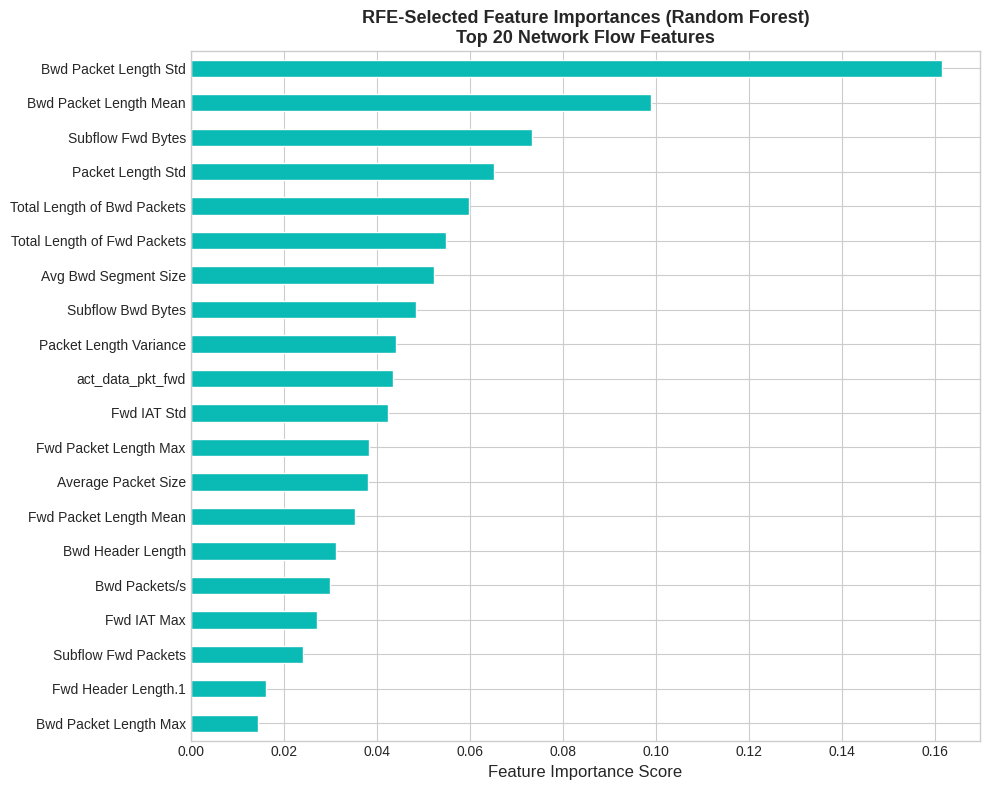

In [17]:
# Visualise RFE feature importance
# Get feature importances from the fitted RF inside RFE
importances = rfe.estimator_.feature_importances_
feat_imp = pd.Series(importances, index=selected_features).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
feat_imp.plot(kind='barh', ax=ax, color=TEAL, edgecolor='white')
ax.set_title('RFE-Selected Feature Importances (Random Forest)\nTop 20 Network Flow Features',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Feature Importance Score', fontsize=12)
plt.tight_layout()
plt.savefig('rfe_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

---
## CELL 17 — Save Preprocessed Data for Phase 2

Save all artefacts needed for model training in Phase 2.

In [18]:
import joblib

# Create output directory
SAVE_DIR = '/content/drive/MyDrive/Thesis/preprocessed/'
os.makedirs(SAVE_DIR, exist_ok=True)

# Save arrays
np.save(f'{SAVE_DIR}X_train_sm.npy', X_train_sm)   # SMOTE-balanced training features
np.save(f'{SAVE_DIR}y_train_sm.npy', y_train_sm)   # SMOTE-balanced training labels
np.save(f'{SAVE_DIR}X_test.npy', X_test.values)    # Test features (NOT SMOTE'd)
np.save(f'{SAVE_DIR}y_test.npy', y_test)            # Test labels
np.save(f'{SAVE_DIR}X_train_pca.npy', X_train_pca) # PCA-reduced training data
np.save(f'{SAVE_DIR}X_test_pca.npy', X_test_pca)   # PCA-reduced test data

# Save fitted objects for reuse
joblib.dump(scaler, f'{SAVE_DIR}scaler.pkl')
joblib.dump(pca, f'{SAVE_DIR}pca.pkl')
joblib.dump(le, f'{SAVE_DIR}label_encoder.pkl')
joblib.dump(rfe, f'{SAVE_DIR}rfe.pkl')
joblib.dump(selected_features, f'{SAVE_DIR}selected_features.pkl')

# Save column names
pd.Series(X.columns.tolist()).to_csv(f'{SAVE_DIR}feature_names.csv', index=False)

print(' All Phase 1 outputs saved to Google Drive')
print(f'Location: {SAVE_DIR}')
print('\nSaved files:')
for f in os.listdir(SAVE_DIR):
    size = os.path.getsize(f'{SAVE_DIR}{f}') / 1024**2
    print(f'  {f} ({size:.1f} MB)')

 All Phase 1 outputs saved to Google Drive
Location: /content/drive/MyDrive/Thesis/preprocessed/

Saved files:
  X_train_pca.npy (712.4 MB)
  X_test_pca.npy (23.8 MB)
  X_train_sm.npy (3473.1 MB)
  y_train_sm.npy (44.5 MB)
  X_test.npy (116.2 MB)
  y_test.npy (1.5 MB)
  label_encoder.pkl (0.0 MB)
  scaler.pkl (0.0 MB)
  feature_names.csv (0.0 MB)
  pca.pkl (0.0 MB)
  selected_features.pkl (0.0 MB)
  rfe.pkl (4.2 MB)


---
## CELL 18 — Phase 1 Summary Report

In [19]:
print('=' * 60)
print('PHASE 1 COMPLETE — SUMMARY REPORT')
print('=' * 60)
print(f'\nDataset: CICIDS2017 (Canadian Institute for Cybersecurity, 2017)')
print(f'Original rows:         1,048,575')
print(f'After cleaning:        {len(df):,}')
print(f'Features:              79 network flow features')
print(f'Attack categories:     10')
print()
print('PRE-PROCESSING PIPELINE APPLIED:')
print('   1. Label encoding fixes (Web Attack labels)')
print('   2. Null value removal')
print('   3. Infinite value replacement')
print('   4. Duplicate row removal')
print('   5. StandardScaler normalisation')
print('   6. Stratified 80/20 train/test split')
print('   7. SMOTE oversampling (training set only)')
print('   8. PCA dimensionality reduction (95% variance retained)')
print('   9. RFE feature selection (top 20 features identified)')
print()
print('KEY FINDINGS FOR DISSERTATION:')
print(f'  - Class imbalance: {benign/total*100:.1f}% BENIGN / {attack/total*100:.1f}% ATTACK')
print(f'  - PCA reduced features from 79 → {n_components_kept} components (95% variance)')
print(f'  - Infinite values found in Flow Bytes/s and Flow Packets/s (known CICIDS2017 issue)')
print(f'  - {n_duplicates:,} duplicate rows removed')
print()
print('NEXT: Phase 2 — Model Training (Random Forest, XGBoost, LSTM, Isolation Forest)')
print('=' * 60)

PHASE 1 COMPLETE — SUMMARY REPORT

Dataset: CICIDS2017 (Canadian Institute for Cybersecurity, 2017)
Original rows:         1,048,575
After cleaning:        975,899
Features:              79 network flow features
Attack categories:     10

PRE-PROCESSING PIPELINE APPLIED:
   1. Label encoding fixes (Web Attack labels)
   2. Null value removal
   3. Infinite value replacement
   4. Duplicate row removal
   5. StandardScaler normalisation
   6. Stratified 80/20 train/test split
   7. SMOTE oversampling (training set only)
   8. PCA dimensionality reduction (95% variance retained)
   9. RFE feature selection (top 20 features identified)

KEY FINDINGS FOR DISSERTATION:
  - Class imbalance: 74.8% BENIGN / 25.2% ATTACK
  - PCA reduced features from 79 → 16 components (95% variance)
  - Infinite values found in Flow Bytes/s and Flow Packets/s (known CICIDS2017 issue)
  - 72,246 duplicate rows removed

NEXT: Phase 2 — Model Training (Random Forest, XGBoost, LSTM, Isolation Forest)


In [20]:
from google.colab import drive
drive.mount('/content/drive')

import json, base64, os

# ---- point this at your Phase 1 notebook file in Drive ----
NOTEBOOK_PATH = '/content/drive/MyDrive/Thesis/Thesis_Phase1_EDA_Preprocessing.ipynb'
FIG_DIR = '/content/drive/MyDrive/Thesis/figures/'
# -------------------------------------------------------------

os.makedirs(FIG_DIR, exist_ok=True)

with open(NOTEBOOK_PATH, 'r') as f:
    nb = json.load(f)

# Match cells by a unique snippet of their own source code, not by cell number —
# this way it still works even if you've added/removed cells since.
markers = {
    "savefig('class_distribution.png'":      'class_distribution.png',
    "savefig('feature_distributions.png'":   'feature_distributions.png',
    "savefig('correlation_heatmap.png'":     'correlation_heatmap.png',
    "savefig('pca_explained_variance.png'":  'pca_explained_variance.png',
    "savefig('pca_risk_clusters.png'":       'pca_risk_clusters.png',
    "savefig('rfe_feature_importance.png'":  'rfe_feature_importance.png',
}

saved = []
for cell in nb['cells']:
    src = ''.join(cell.get('source', []))
    for marker, fname in markers.items():
        if marker in src:
            found_image = False
            for output in cell.get('outputs', []):
                data = output.get('data', {})
                if 'image/png' in data:
                    b64 = data['image/png']
                    if isinstance(b64, list):
                        b64 = ''.join(b64)
                    with open(os.path.join(FIG_DIR, fname), 'wb') as out:
                        out.write(base64.b64decode(b64))
                    saved.append(fname)
                    found_image = True
                    break
            if not found_image:
                print(f'⚠️ No saved image found for {fname} — that cell may need to be re-run once.')

print(f'\n Saved {len(saved)}/6 figures to {FIG_DIR}')
for f in saved:
    print(' ', f)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
⚠️ No saved image found for class_distribution.png — that cell may need to be re-run once.
⚠️ No saved image found for feature_distributions.png — that cell may need to be re-run once.
⚠️ No saved image found for correlation_heatmap.png — that cell may need to be re-run once.
⚠️ No saved image found for pca_explained_variance.png — that cell may need to be re-run once.
⚠️ No saved image found for pca_risk_clusters.png — that cell may need to be re-run once.
⚠️ No saved image found for rfe_feature_importance.png — that cell may need to be re-run once.

 Saved 6/6 figures to /content/drive/MyDrive/Thesis/figures/
  class_distribution.png
  feature_distributions.png
  correlation_heatmap.png
  pca_explained_variance.png
  pca_risk_clusters.png
  rfe_feature_importance.png
